In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

sns.set_style()
sns.set_theme()

In [13]:
'''
features:

"length" - longest shell measurement.
"diameter" - perpendicular to the length.
"height" - measured with meat in the shell.
"whole_wt" - whole abalone weight.
"shucked_wt" - the weight of abalone meat.
"viscera_wt" - gut-weight.
"shell_wt" - the weight of the dried shell.

target:
"age" - the age of the abalone.
'''

data = pd.read_csv('data/abalone2.csv')
data

,length,diameter,height,whole_wt,shucked_wt,viscera_wt,shell_wt,age
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,16.5
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,8.5
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,10.5
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,11.5
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,8.5
...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,12.5
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,11.5
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,10.5
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,11.5


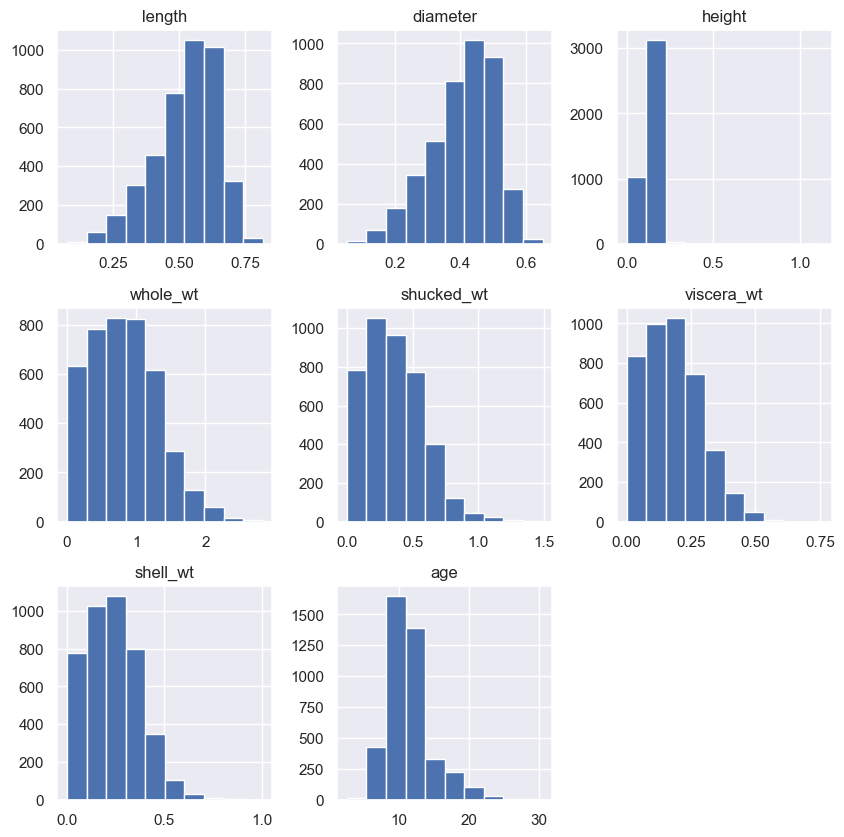

In [14]:
_ = data.hist(figsize=(10,10))

In [15]:
num_plots // cols_per_row

2

In [16]:
num_plots % cols_per_row > 0

True

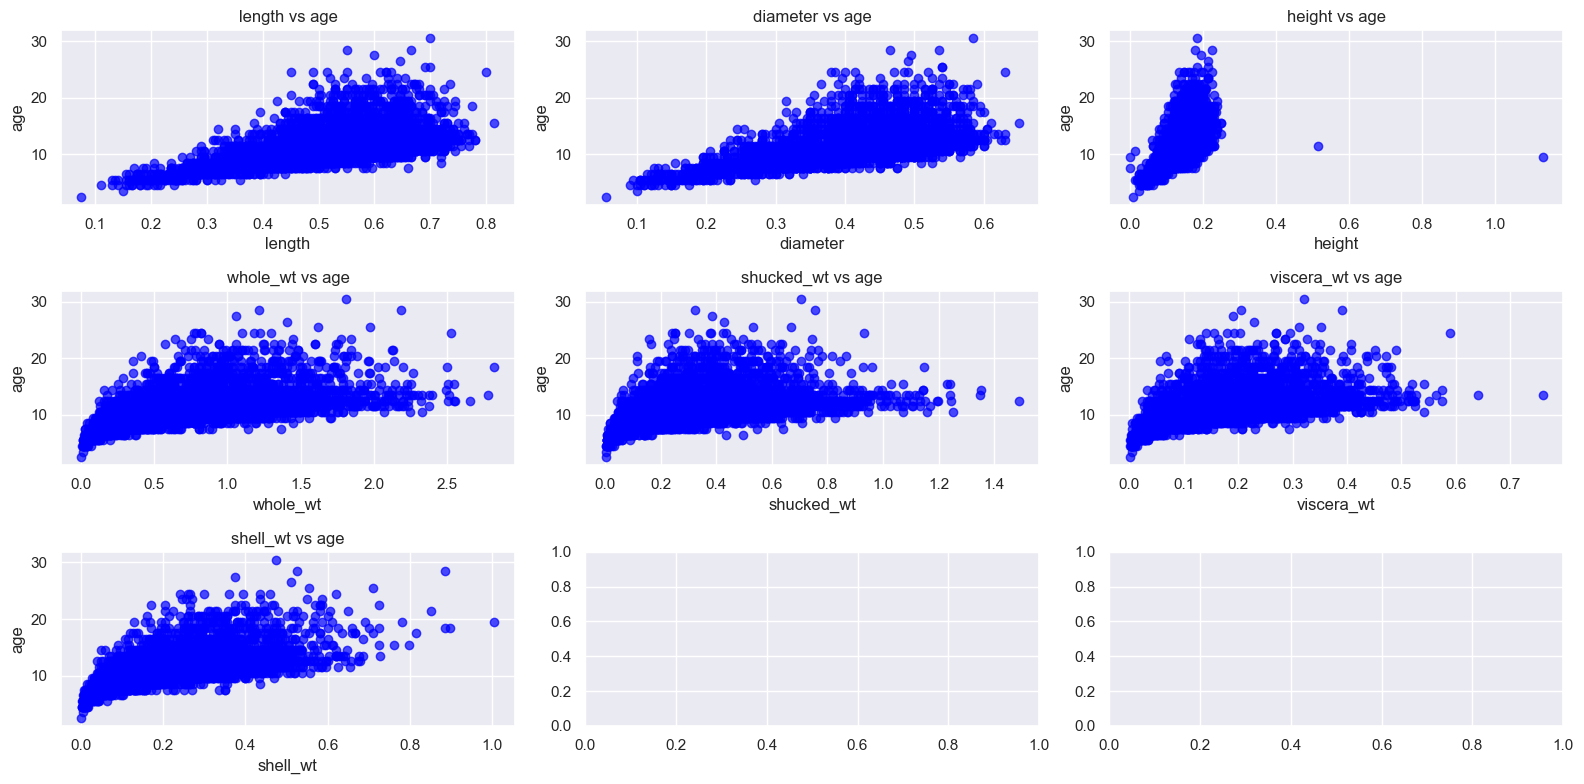

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Specify target column
target_column = "age"  # Replace with actual target column name

# Filter out the target column from features
feature_columns = [col for col in data.columns if col != target_column]

# Set grid layout
cols_per_row = 3  # Adjust for your preference
num_plots = len(feature_columns)
rows = (num_plots // cols_per_row) + (num_plots % cols_per_row > 0)

# Create subplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 8))
axes = axes.flatten()  # Flatten in case of multiple rows

# Plot each feature against the target column
for i, col in enumerate(feature_columns):
    axes[i].scatter(data[col], data[target_column], alpha=0.7, color="blue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_column)
    axes[i].set_title(f"{col} vs {target_column}")

# Remove empty subplots if any
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [18]:
i

6

In [19]:
data.columns

Index(['length', 'diameter', 'height', 'whole_wt', 'shucked_wt', 'viscera_wt',
       'shell_wt', 'age'],
      dtype='object')

In [20]:
feature_names = ['length', 'diameter', 'height', 'whole_wt', 'shucked_wt', 'viscera_wt', 'shell_wt']
features = data[feature_names]
target = data['age']

In [21]:
lr = LinearRegression()

In [22]:
lr.fit(features, target)

LinearRegression()

In [23]:
lr.coef_

array([ -1.57189738,  13.36091617,  11.82607248,   9.24741445,
       -20.21391319,  -9.82967548,   8.57624241])

In [24]:
lr.feature_names_in_

array(['length', 'diameter', 'height', 'whole_wt', 'shucked_wt',
       'viscera_wt', 'shell_wt'], dtype=object)

In [25]:
predicted_values = lr.predict(features)

In [26]:
root_mean_squared_error(target, predicted_values)

2.215679763823951

In [27]:
r2_score(target, predicted_values)

0.5276299399919839